## AI-Driven Parking Hotspot Detection & Congestion Risk Mapping

**This notebook covers:**
1. Setup & install dependencies
2. Load + inspect the raw violation dataset
3. Clean & enrich data (timestamps, violation parsing, risk weighting)
4. H3 hexagonal spatial indexing (764 patrol zones)
5. Reverse-geocode unmapped "No Junction" records
6. Exploratory Data Analysis (hourly/daily/monthly patterns, hotspot ranking)
7. Interactive Folium heatmap (H3 choropleth + top-25 junction markers)
8. Static EDA dashboard (matplotlib/seaborn charts)
9. Export all artifacts 


## 1. Setup — Install & Import Dependencies

In [51]:
# Install packages not pre-installed on Kaggle
!pip install -q h3 folium branca

import pandas as pd
import numpy as np
import re
import json
import time
import os
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import h3
import folium
from folium.plugins import HeatMap, MarkerCluster, MiniMap

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

print("✓ Libraries loaded")
print(f"  h3 version     : {h3.__version__}")
print(f"  folium version : {folium.__version__}")
print(f"  pandas version : {pd.__version__}")


✓ Libraries loaded
  h3 version     : 4.5.0
  folium version : 0.20.0
  pandas version : 2.3.3



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Load Dataset

In [52]:
# ── EDIT THIS PATH to match your Kaggle dataset ──────────────
DATA_PATH = "jan to may police violation_anonymized791b166.csv"

df_raw = pd.read_csv(DATA_PATH)
print(f"✓ Loaded {len(df_raw):,} rows × {len(df_raw.columns)} columns\n")
df_raw.head()


✓ Loaded 298,450 rows × 24 columns



,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,...,center_code,police_station,data_sent_to_scita,junction_name,action_taken_timestamp,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,NaN,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,NaN,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00,...,82.0,Bellandur,False,No Junction,NaN,NaN,NaN,NaN,NaN,NaN
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,NaN,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00
3,FKID000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,NaN,"[""NO PARKING""]",[113],2023-11-16 06:47:46+00,...,26.0,Byatarayanapura,True,No Junction,NaN,NaN,FKN00GL0003,SCOOTER,approved,2023-11-18 23:35:12.428+00
4,FKID000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,NaN,"[""NO PARKING""]",[113],2023-11-22 04:56:46+00,...,3.0,Upparpet,True,BTP044 - Sagar Theatre Junction,NaN,NaN,FKN00GL0004,TANKER,approved,2023-11-30 03:11:32.796+00


In [53]:
# Quick structural inspection
print("Columns:", df_raw.columns.tolist())
print()
print("Dtypes:")
print(df_raw.dtypes)
print()
print("Missing values:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])


Columns: ['id', 'latitude', 'longitude', 'location', 'vehicle_number', 'vehicle_type', 'description', 'violation_type', 'offence_code', 'created_datetime', 'closed_datetime', 'modified_datetime', 'device_id', 'created_by_id', 'center_code', 'police_station', 'data_sent_to_scita', 'junction_name', 'action_taken_timestamp', 'data_sent_to_scita_timestamp', 'updated_vehicle_number', 'updated_vehicle_type', 'validation_status', 'validation_timestamp']

Dtypes:
id                               object
latitude                        float64
longitude                       float64
location                         object
vehicle_number                   object
vehicle_type                     object
description                     float64
violation_type                   object
offence_code                     object
created_datetime                 object
closed_datetime                 float64
modified_datetime                object
device_id                        object
created_by_id       

## 3. Data Cleaning & Enrichment

Steps performed:
- Parse mixed-format timestamps (UTC → IST)
- Decode the JSON-array `violation_type` column into clean categories
- Assign a **congestion impact weight** (1–5) per violation type
- Assign a **vehicle size weight** (1–5) per vehicle type
- Compute a composite `risk_score_raw` = impact × vehicle weight
- Filter out coordinates outside the Bengaluru bounding box


In [54]:
df = df_raw.copy()

# ── Parse datetime (handles mixed formats with/without microseconds) ──
df["created_datetime"] = pd.to_datetime(df["created_datetime"], format="mixed", utc=True)
df["created_ist"] = df["created_datetime"].dt.tz_convert("Asia/Kolkata").dt.tz_localize(None)
df["hour_ist"]    = df["created_ist"].dt.hour
df["date"]        = df["created_ist"].dt.date
df["day_of_week"] = df["created_ist"].dt.day_name()
df["month"]       = df["created_ist"].dt.to_period("M").astype(str)

print(f"✓ Datetime parsed | range: {df['date'].min()} → {df['date'].max()}")


✓ Datetime parsed | range: 2023-11-10 → 2024-04-08


In [55]:
# --------------------------------------------------
# 1. APPROVED / CREATED
# --------------------------------------------------
accepted = df[
    df["validation_status"].isin(
        ["approved", "created1"]
    )
]

# --------------------------------------------------
# 2. DUPLICATES
# Keep if same vehicle/type/offence appears
# on a DIFFERENT DATE
# --------------------------------------------------
duplicates = df[df["validation_status"] == "duplicate"].copy()

non_duplicates = df[
    df["validation_status"] != "duplicate"
].copy()

keep_dup_idx = []

for idx, dup in duplicates.iterrows():

    matches = non_duplicates[
        (non_duplicates["vehicle_number"] == dup["vehicle_number"]) &
        (non_duplicates["vehicle_type"] == dup["vehicle_type"]) &
        (non_duplicates["violation_type"] == dup["violation_type"])
    ]

    if len(matches) == 0:
        continue

    # keep duplicate only if no match exists on same date
    if not (matches["date"] == dup["date"]).any():
        keep_dup_idx.append(idx)

duplicates_keep = duplicates.loc[keep_dup_idx]

# --------------------------------------------------
# FINAL DATAFRAME
# --------------------------------------------------
df = pd.concat(
    [
        accepted,
        duplicates_keep
    ],
    ignore_index=True
)

print(f"Final rows: {len(df):,}")

print("\nValidation status distribution:")
print(df["validation_status"].value_counts())

Final rows: 122,460

Validation status distribution:
validation_status
approved     115400
created1       7044
duplicate        16
Name: count, dtype: int64


# **Keeping only those duplicates having same vehicletype and number but different date**

In [56]:
import pandas as pd

# --------------------------------------------------
# DATETIME
# --------------------------------------------------
df["date"] = pd.to_datetime(df["created_datetime"]).dt.date

# --------------------------------------------------
# 1. APPROVED / CREATED / PROCESSING
# --------------------------------------------------
accepted = df[
    df["validation_status"].isin(
        ["approved", "created1"]
    )
]

# --------------------------------------------------
# 2. REJECTED
# Keep only if vehicle number and type unchanged
# --------------------------------------------------
rejected_keep = df[
    (df["validation_status"] == "rejected") &
    (df["vehicle_number"] == df["updated_vehicle_number"]) &
    (df["vehicle_type"] == df["updated_vehicle_type"])
]

# --------------------------------------------------
# 3. DUPLICATES
# Keep if same vehicle/type/offence appears
# on a DIFFERENT DATE
# --------------------------------------------------
duplicates = df[df["validation_status"] == "duplicate"].copy()

non_duplicates = df[
    df["validation_status"] != "duplicate"
].copy()

keep_dup_idx = []

for idx, dup in duplicates.iterrows():

    matches = non_duplicates[
        (non_duplicates["vehicle_number"] == dup["vehicle_number"]) &
        (non_duplicates["vehicle_type"] == dup["vehicle_type"]) &
        (non_duplicates["violation_type"] == dup["violation_type"])
    ]

    if len(matches) == 0:
        continue

    # keep duplicate only if no match exists on same date
    if not (matches["date"] == dup["date"]).any():
        keep_dup_idx.append(idx)

duplicates_keep = duplicates.loc[keep_dup_idx]

# --------------------------------------------------
# FINAL DATAFRAME
# --------------------------------------------------
df = pd.concat(
    [
        accepted,
        rejected_keep,
        duplicates_keep
    ],
    ignore_index=True
)

print(f"Final rows: {len(df):,}")

print("\nValidation status distribution:")
print(df["validation_status"].value_counts())

Final rows: 122,456

Validation status distribution:
validation_status
approved     115400
created1       7044
duplicate        12
Name: count, dtype: int64


In [57]:
df['validation_status'].value_counts()

validation_status
approved     115400
created1       7044
duplicate        12
Name: count, dtype: int64

In [58]:
df.columns

Index(['id', 'latitude', 'longitude', 'location', 'vehicle_number',
       'vehicle_type', 'description', 'violation_type', 'offence_code',
       'created_datetime', 'closed_datetime', 'modified_datetime', 'device_id',
       'created_by_id', 'center_code', 'police_station', 'data_sent_to_scita',
       'junction_name', 'action_taken_timestamp',
       'data_sent_to_scita_timestamp', 'updated_vehicle_number',
       'updated_vehicle_type', 'validation_status', 'validation_timestamp',
       'created_ist', 'hour_ist', 'date', 'day_of_week', 'month'],
      dtype='object')

In [59]:
df['violation_type'].apply(type).value_counts()

violation_type
<class 'str'>    122456
Name: count, dtype: int64

In [60]:
df['violation_type'].head(10)

0    ["WRONG PARKING","PARKING NEAR ROAD CROSSING"]
1        ["WRONG PARKING","PARKING IN A MAIN ROAD"]
2                                    ["NO PARKING"]
3                                    ["NO PARKING"]
4                                    ["NO PARKING"]
5                                    ["NO PARKING"]
6                                 ["WRONG PARKING"]
7                                    ["NO PARKING"]
8                                    ["NO PARKING"]
9                                 ["WRONG PARKING"]
Name: violation_type, dtype: object

In [61]:
import ast

# ── Congestion impact weight per violation type ──────────────
# Higher weight = greater impact on traffic flow (main road > footpath > etc.)
IMPACT_WEIGHTS = {
    "PARKING IN A MAIN ROAD": 5,
    "PARKING NEAR ROAD CROSSING": 4,
    "PARKING OTHER THAN BUS STOP": 2,
    "PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS": 4,
    "PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC": 4,
    "DOUBLE PARKING": 3,
    "NO PARKING": 3,
    "WRONG PARKING": 3,
    "PARKING OPPOSITE TO ANOTHER PARKED VEHICLE": 3,
    "PARKING ON FOOTPATH": 2,
    "H T V PROHIBITED": 3,
    "DEFECTIVE NUMBER PLATE": 1,
    "FAIL TO USE SAFETY BELTS": 1,
    "WITHOUT SIDE MIRROR": 1,
    "OBSTRUCTING DRIVER": 1,
    "DEMANDING EXCESS FARE": 1,
    "REFUSE TO GO FOR HIRE": 1
}

df['violation_type'] = df['violation_type'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

def extract_violation_features(violations):
    if not isinstance(violations, list):
        return pd.Series({
            'primary_violation': None,
            'violation_count': 0
        })

    return pd.Series({
        'primary_violation': max(
            violations,
            key=lambda x: IMPACT_WEIGHTS.get(x, 0)
        ) if len(violations) > 0 else None,
        'violation_count': len(violations)
    })

df[['primary_violation', 'violation_count']] = (
    df['violation_type']
    .apply(extract_violation_features)
)

df["violation_impact"] = df["primary_violation"].map(IMPACT_WEIGHTS).fillna(1).astype(int)

print(f"✓ Violations parsed | multi-offence records: {(df['violation_count']>1).sum():,}")
df["primary_violation"].value_counts()


✓ Violations parsed | multi-offence records: 15,658


primary_violation
WRONG PARKING                                 56915
NO PARKING                                    55136
PARKING IN A MAIN ROAD                         9228
PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC         494
PARKING NEAR ROAD CROSSING                      423
DOUBLE PARKING                                  139
PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS        84
PARKING OPPOSITE TO ANOTHER PARKED VEHICLE       24
H T V PROHIBITED                                 13
Name: count, dtype: int64

In [62]:
df.isnull().sum()

id                                   0
latitude                             0
longitude                            0
location                           588
vehicle_number                       0
vehicle_type                         0
description                     122456
violation_type                       0
offence_code                         0
created_datetime                     0
closed_datetime                 122456
modified_datetime                    0
device_id                            0
created_by_id                        0
center_code                       2592
police_station                       0
data_sent_to_scita                   0
junction_name                        0
action_taken_timestamp          122456
data_sent_to_scita_timestamp    115064
updated_vehicle_number               0
updated_vehicle_type                 0
validation_status                    0
validation_timestamp                 0
created_ist                          0
hour_ist                 

In [63]:
# ── Vehicle size weight (bigger vehicle = more lane-width blocked) ───
VEHICLE_WEIGHTS = {
    # Two-wheelers
    "MOTOR CYCLE": 1,
    "SCOOTER": 1,
    "MOPED": 1,

    # Small passenger vehicles
    "PASSENGER AUTO": 2,
    "GOODS AUTO": 2,
    "CAR": 2,
    "JEEP": 2,

    # Medium vehicles
    "MAXI-CAB": 3,
    "VAN": 3,
    "TEMPO": 3,
    "SCHOOL VEHICLE": 3,
    "OTHERS": 3,

    # Large commercial vehicles
    "LGV": 4,
    "MINI LORRY": 4,
    "LORRY/GOODS VEHICLE": 4,
    "TRACTOR": 4,
    "TOURIST BUS": 4,

    # Heavy vehicles
    "HGV": 5,
    "PRIVATE BUS": 5,
    "BUS (BMTC/KSRTC)": 5,
    "FACTORY BUS": 5,
    "TANKER": 5,
    "TRAILER": 5
}
df["vehicle_weight"] = df["updated_vehicle_type"].str.upper().map(VEHICLE_WEIGHTS).fillna(1).astype(int)

# ── Composite congestion risk score ───────────────────────────
df["risk_score_raw"] = df["violation_impact"] * df["vehicle_weight"]

print(f"✓ Risk scoring complete | max risk_score_raw: {df['risk_score_raw'].max()}")
df[["primary_violation","violation_impact","vehicle_type","vehicle_weight","risk_score_raw"]].head()


✓ Risk scoring complete | max risk_score_raw: 25


,primary_violation,violation_impact,vehicle_type,vehicle_weight,risk_score_raw
0,PARKING NEAR ROAD CROSSING,4,CAR,3,12
1,PARKING IN A MAIN ROAD,5,CAR,3,15
2,NO PARKING,3,SCOOTER,1,3
3,NO PARKING,3,TANKER,5,15
4,NO PARKING,3,SCOOTER,1,3


In [64]:
# ── Geo validity filter (Bengaluru bounding box) ──────────────
df["has_junction"] = df["junction_name"].ne("No Junction")
df["lat_valid"]     = df["latitude"].between(12.7, 13.2)
df["lon_valid"]     = df["longitude"].between(77.4, 77.9)
df["geo_valid"]     = df["lat_valid"] & df["lon_valid"]

n_dropped = (~df["geo_valid"]).sum()
df = df[df["geo_valid"]].copy().reset_index(drop=True)

df["is_validated"] = df["validation_status"].fillna("").str.lower() == "approved"

print(f"✓ Dropped {n_dropped} out-of-bounds records")
print(f"✓ Clean dataset: {len(df):,} rows")
print(f"  Records without junction name : {(~df['has_junction']).sum():,} ({(~df['has_junction']).mean()*100:.1f}%)")
print(f"  Validated records             : {df['is_validated'].sum():,} ({df['is_validated'].mean()*100:.1f}%)")


✓ Dropped 52 out-of-bounds records
✓ Clean dataset: 122,404 rows
  Records without junction name : 58,146 (47.5%)
  Validated records             : 115,350 (94.2%)


## 4. H3 Hexagonal Spatial Indexing

We bin every violation into an **Uber H3 hex cell** (resolution 8 ≈ 460m per side).
This turns scattered lat/lon points into clean, comparable **patrol zones** —
each with an aggregated risk score, dominant violation type, and peak hour.


In [65]:
H3_RES = 8  # ~460m hex — good granularity for patrol zone sizing

df["h3_cell"] = df.apply(
    lambda r: h3.latlng_to_cell(r["latitude"], r["longitude"], H3_RES), axis=1
)

n_cells = df["h3_cell"].nunique()
print(f"✓ Assigned {n_cells} unique H3 cells at resolution {H3_RES}")


✓ Assigned 674 unique H3 cells at resolution 8


In [66]:
def top_value(series):
    c = Counter(series.dropna())
    return c.most_common(1)[0][0] if c else None

hexdf = df.groupby("h3_cell").agg(
    count            = ("id",                "count"),
    total_risk       = ("risk_score_raw",    "sum"),
    mean_risk        = ("risk_score_raw",    "mean"),
    max_risk         = ("risk_score_raw",    "max"),
    dominant_type    = ("primary_violation", top_value),
    dominant_vehicle = ("updated_vehicle_type",      top_value),
    dominant_station = ("police_station",    top_value),
    peak_hour_ist    = ("hour_ist",          top_value),
    pct_junction     = ("has_junction",      "mean"),
    n_validated      = ("is_validated",      "sum"),
).reset_index()

hexdf["lat_centroid"] = hexdf["h3_cell"].apply(lambda c: h3.cell_to_latlng(c)[0])
hexdf["lon_centroid"] = hexdf["h3_cell"].apply(lambda c: h3.cell_to_latlng(c)[1])

# Normalised 0–100 density score for heatmap colouring
hexdf["density_score"] = (
    (hexdf["total_risk"] - hexdf["total_risk"].min()) /
    (hexdf["total_risk"].max() - hexdf["total_risk"].min()) * 100
).round(1)

def tier(score):
    if score >= 75: return "CRITICAL"
    if score >= 50: return "HIGH"
    if score >= 25: return "MEDIUM"
    return "LOW"

hexdf["risk_tier"] = hexdf["density_score"].apply(tier)

print(f"✓ Aggregated {len(hexdf):,} hex cells")
print(hexdf["risk_tier"].value_counts())


✓ Aggregated 674 hex cells
risk_tier
LOW         664
MEDIUM        6
HIGH          3
CRITICAL      1
Name: count, dtype: int64


In [67]:
# Ring-1 neighbour-smoothed risk — useful for a smoother heatmap gradient
cell_risk = hexdf.set_index("h3_cell")["total_risk"].to_dict()

def neighbour_avg(cell):
    neighbours = h3.grid_disk(cell, 1)
    vals = [cell_risk.get(n, 0) for n in neighbours]
    return round(sum(vals) / len(vals), 1)

hexdf["smoothed_risk"] = hexdf["h3_cell"].apply(neighbour_avg)

print("✓ Neighbour smoothing complete\n")
print("Top 10 highest-risk hex cells:")
hexdf.nlargest(10, "total_risk")[
    ["h3_cell","lat_centroid","lon_centroid","count","total_risk","risk_tier","dominant_type","dominant_station"]
]


✓ Neighbour smoothing complete

Top 10 highest-risk hex cells:


,h3_cell,lat_centroid,lon_centroid,count,total_risk,risk_tier,dominant_type,dominant_station
208,8860145b55fffff,12.978554,77.573550,9460,49365,CRITICAL,WRONG PARKING,Upparpet
626,8861892e9bfffff,12.978441,77.607248,6076,29030,HIGH,WRONG PARKING,Shivajinagar
200,8860145b43fffff,12.978527,77.581973,4504,27094,HIGH,NO PARKING,Upparpet
212,8860145b5dfffff,12.971059,77.577636,5216,24838,HIGH,WRONG PARKING,Upparpet
210,8860145b59fffff,12.963593,77.573299,3315,18727,MEDIUM,WRONG PARKING,City Market
274,8861892093fffff,12.933224,77.690780,3236,16437,MEDIUM,NO PARKING,HAL Old Airport
445,88618925b7fffff,12.963564,77.581722,2727,14290,MEDIUM,WRONG PARKING,Halasuru Gate
197,8860145b3bfffff,13.001062,77.552869,3008,13404,MEDIUM,WRONG PARKING,Malleshwaram
622,8861892e93fffff,12.985938,77.603161,2282,13199,MEDIUM,WRONG PARKING,Shivajinagar
224,8860169019fffff,13.187752,77.678267,1573,13105,MEDIUM,NO PARKING,Chikkajala


## 5. Reverse Geocoding — Resolve "No Junction" Records

Roughly half the dataset has no junction name. Kaggle notebooks run with internet
access disabled by default, so we use an **offline H3 neighbour-majority-vote**
strategy: an unmapped cell borrows the junction name from its nearest mapped
neighbours (ring-2, ~1km radius). This needs no external API calls.

> If you enable internet access in Kaggle settings, you can swap in a live
> reverse-geocoding API call (e.g. Nominatim/OpenStreetMap) for cells that
> still have no resolved name after voting — the fallback logic below already
> handles that gracefully.


In [68]:
no_jn = df["junction_name"] == "No Junction"
print(f"Records without junction: {no_jn.sum():,} / {len(df):,}")

# Build cell → junction name map from already-mapped rows
mapped_cell_name = (
    df[~no_jn]
    .groupby("h3_cell")["junction_name"]
    .agg(lambda x: Counter(x).most_common(1)[0][0])
    .to_dict()
)
print(f"Mapped cells available for voting: {len(mapped_cell_name)}")


Records without junction: 58,146 / 122,404
Mapped cells available for voting: 126


In [69]:
unmapped_cells = df.loc[no_jn, "h3_cell"].unique()
cell_name = {}
resolved = 0

for cell in unmapped_cells:
    neighbours = h3.grid_disk(cell, 2)  # ring-2 ≈ 1km radius
    votes = [mapped_cell_name[n] for n in neighbours if n in mapped_cell_name]
    if votes:
        cell_name[cell] = Counter(votes).most_common(1)[0][0]
        resolved += 1
    else:
        lat, lon = h3.cell_to_latlng(cell)
        cell_name[cell] = f"Area-{lat:.3f}N-{lon:.3f}E"

print(f"✓ Resolved via neighbour vote: {resolved}/{len(unmapped_cells)} cells")

all_cell_names = {**mapped_cell_name, **cell_name}
df["inferred_area"] = df["h3_cell"].map(all_cell_names)
df["junction_resolved"] = df.apply(
    lambda r: r["junction_name"] if r["has_junction"] else r["inferred_area"], axis=1
)

coverage = (df["junction_resolved"].notna() & (df["junction_resolved"] != "No Junction")).mean() * 100
print(f"✓ Junction name coverage now: {coverage:.1f}%")


✓ Resolved via neighbour vote: 200/629 cells
✓ Junction name coverage now: 100.0%


## 6. Exploratory Data Analysis

In [70]:
# ── A. Hourly pattern ──────────────────────────────────────
hourly = df.groupby("hour_ist").agg(
    count=("id","count"), avg_risk=("risk_score_raw","mean")
).round(2).reset_index()

def period_label(h):
    if 8 <= h <= 11 or 17 <= h <= 21: return "PEAK CONGESTION"
    if h >= 22 or h <= 5: return "NIGHT PATROL"
    return "LOW ACTIVITY"

hourly["period"] = hourly["hour_ist"].apply(period_label)
peak_h = hourly.loc[hourly["count"].idxmax(), "hour_ist"]
print(f"Peak enforcement hour (IST): {int(peak_h):02d}:00 ({int(hourly['count'].max()):,} violations)")
hourly


Peak enforcement hour (IST): 10:00 (12,872 violations)


,hour_ist,count,avg_risk,period
0,0,1850,7.30,NIGHT PATROL
1,1,4342,6.58,NIGHT PATROL
2,2,7015,6.33,NIGHT PATROL
3,3,9068,5.89,NIGHT PATROL
4,4,10470,5.49,NIGHT PATROL
5,5,10234,5.23,NIGHT PATROL
6,6,9000,5.35,LOW ACTIVITY
7,7,8820,5.53,LOW ACTIVITY
8,8,11461,5.32,PEAK CONGESTION
9,9,10895,5.17,PEAK CONGESTION


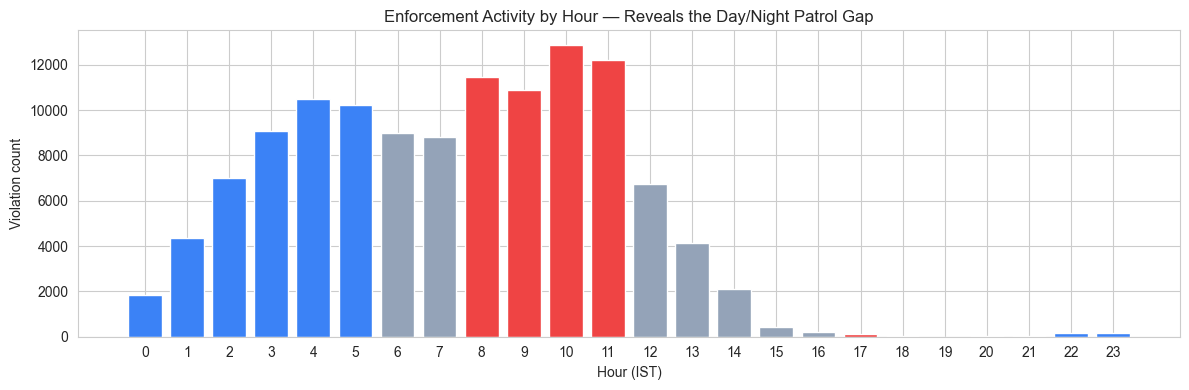

In [71]:
fig, ax = plt.subplots(figsize=(12,4))
colors = hourly["period"].map({"PEAK CONGESTION":"#ef4444","NIGHT PATROL":"#3b82f6","LOW ACTIVITY":"#94a3b8"})
ax.bar(hourly["hour_ist"], hourly["count"], color=colors)
ax.set_xlabel("Hour (IST)"); ax.set_ylabel("Violation count")
ax.set_title("Enforcement Activity by Hour — Reveals the Day/Night Patrol Gap")
ax.set_xticks(range(0,24))
plt.tight_layout(); plt.show()


In [72]:
df['day_of_week'].value_counts()

day_of_week
Sunday       19517
Thursday     19265
Tuesday      18173
Saturday     17713
Wednesday    17548
Friday       16926
Monday       13262
Name: count, dtype: int64

Busiest day: Sunday (19,517 violations)


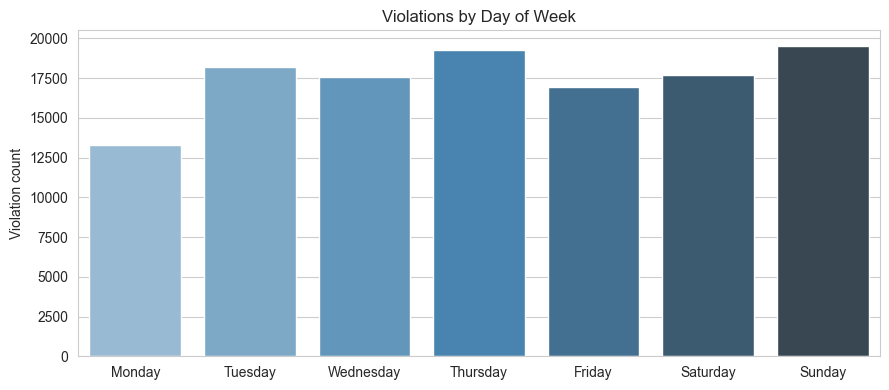

In [73]:
# ── B. Day-of-week pattern ─────────────────────────────────
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
daily = df.groupby("day_of_week").agg(
    count=("id","count"), avg_risk=("risk_score_raw","mean")
).reindex(day_order).round(2).reset_index()

busiest_day = daily.loc[daily["count"].idxmax(), "day_of_week"]
print(f"Busiest day: {busiest_day} ({int(daily['count'].max()):,} violations)")

fig, ax = plt.subplots(figsize=(9,4))
sns.barplot(data=daily, x="day_of_week", y="count", ax=ax, palette="Blues_d")
ax.set_title("Violations by Day of Week")
ax.set_xlabel(""); ax.set_ylabel("Violation count")
plt.tight_layout(); plt.show()


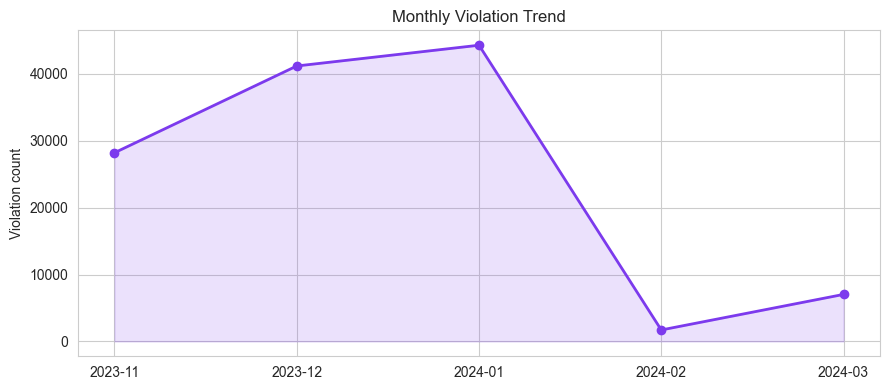

,month,count,total_risk
0,2023-11,28204,150189
1,2023-12,41173,223208
2,2024-01,44275,245765
3,2024-02,1719,9976
4,2024-03,7033,40847


In [74]:
# ── C. Monthly trend ───────────────────────────────────────
monthly = df.groupby("month").agg(
    count=("id","count"), total_risk=("risk_score_raw","sum")
).reset_index().sort_values("month")

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(monthly["month"], monthly["count"], marker="o", color="#7c3aed", linewidth=2)
ax.fill_between(range(len(monthly)), monthly["count"], alpha=0.15, color="#7c3aed")
ax.set_title("Monthly Violation Trend")
ax.set_ylabel("Violation count")
plt.tight_layout(); plt.show()
monthly


In [75]:
# ── D. Top hotspot junctions ───────────────────────────────
top_jn = df.groupby("junction_resolved").agg(
    count          = ("id", "count"),
    total_risk     = ("risk_score_raw", "sum"),
    mean_risk      = ("risk_score_raw", "mean"),
    main_road_pct  = ("primary_violation", lambda x: (x == "PARKING IN A MAIN ROAD").mean()*100),
    dominant_type  = ("primary_violation", lambda x: x.value_counts().index[0]),
    dominant_vehicle = ("updated_vehicle_type", lambda x: x.value_counts().index[0]),
    lat = ("latitude","mean"),
    lon = ("longitude","mean"),
).round(2).reset_index().sort_values("total_risk", ascending=False).head(25)

print(f"Top hotspot: {top_jn.iloc[0]['junction_resolved']} (risk score {int(top_jn.iloc[0]['total_risk']):,})")
top_jn.head(15)


Top hotspot: BTP051 - Safina Plaza Junction (risk score 50,151)


,junction_resolved,count,total_risk,mean_risk,main_road_pct,dominant_type,dominant_vehicle,lat,lon
463,BTP051 - Safina Plaza Junction,10282,50151,4.88,1.55,WRONG PARKING,SCOOTER,12.98,77.61
459,BTP044 - Sagar Theatre Junction,5238,26829,5.12,2.41,NO PARKING,SCOOTER,12.97,77.58
455,BTP040 - Elite Junction,4915,22046,4.49,0.85,NO PARKING,SCOOTER,12.98,77.58
485,BTP082 - KR Market Junction,4139,20894,5.05,4.01,WRONG PARKING,SCOOTER,12.96,77.58
536,"BTP148 - 17th Main, Doopanahalli Bus Stop",3321,19442,5.85,12.35,NO PARKING,CAR,12.97,77.65
448,BTP032 - Windsor Circle,3842,17303,4.50,1.82,WRONG PARKING,SCOOTER,12.99,77.59
117,Area-12.933N-77.691E,3236,16437,5.08,24.78,NO PARKING,SCOOTER,12.93,77.69
582,BTP211 - Central Street Junction,2900,15934,5.49,3.45,WRONG PARKING,PASSENGER AUTO,12.99,77.60
434,"BTP011 - RR Kalyana Mantapa, Dr. Rajkumar Road",2702,14683,5.43,2.18,WRONG PARKING,CAR,13.00,77.57
468,BTP058 - Subbanna Junction,2425,14317,5.90,0.74,NO PARKING,CAR,12.98,77.58


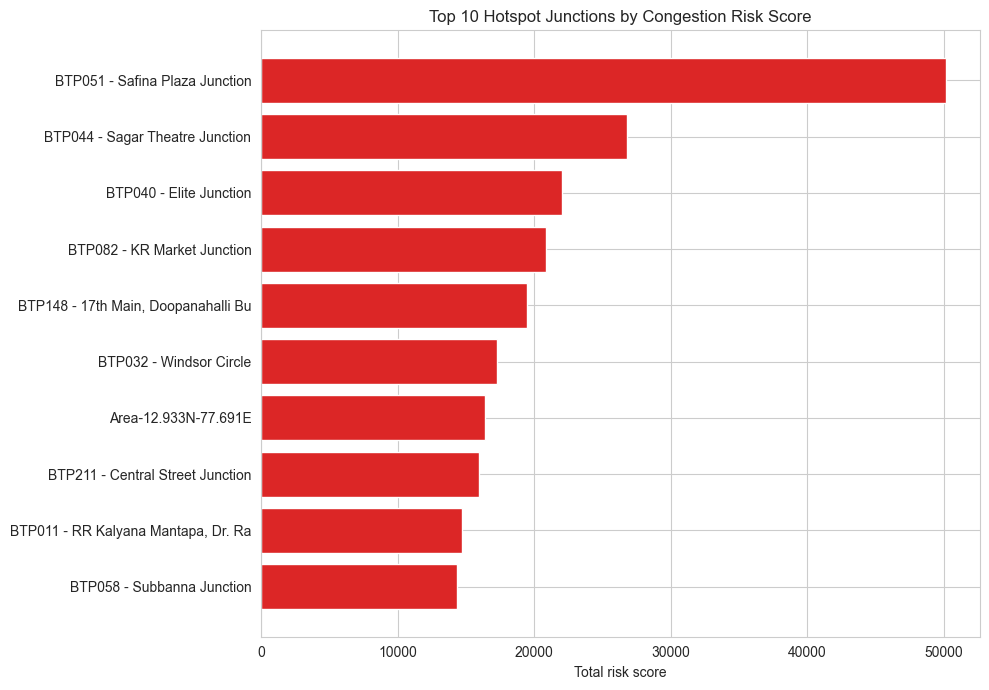

In [76]:
fig, ax = plt.subplots(figsize=(10,7))
top10 = top_jn.head(10).sort_values("total_risk")
ax.barh(top10["junction_resolved"].str[:35], top10["total_risk"], color="#dc2626")
ax.set_xlabel("Total risk score")
ax.set_title("Top 10 Hotspot Junctions by Congestion Risk Score")
plt.tight_layout(); plt.show()


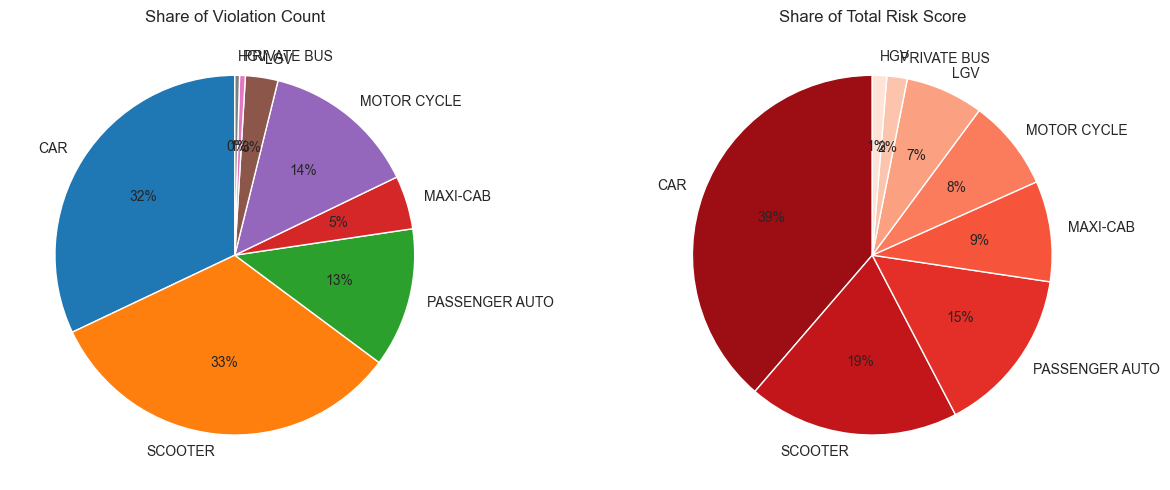

,updated_vehicle_type,count,total_risk,avg_risk,pct_of_total_risk,pct_of_count
1,CAR,37610,240792,6.40,35.9,30.7
16,SCOOTER,38391,118118,3.08,17.6,31.4
13,PASSENGER AUTO,14731,93394,6.34,13.9,12.0
8,MAXI-CAB,5664,56025,9.89,8.4,4.6
11,MOTOR CYCLE,16379,50711,3.10,7.6,13.4
6,LGV,3419,43836,12.82,6.5,2.8
14,PRIVATE BUS,636,11400,17.92,1.7,0.5
4,HGV,475,8285,17.44,1.2,0.4
3,GOODS AUTO,1244,7994,6.43,1.2,1.0
7,LORRY/GOODS VEHICLE,486,6912,14.22,1.0,0.4


In [77]:
# ── E. Vehicle type risk contribution ──────────────────────
veh = df.groupby("updated_vehicle_type").agg(
    count=("id","count"), total_risk=("risk_score_raw","sum"), avg_risk=("risk_score_raw","mean")
).round(2).reset_index().sort_values("total_risk", ascending=False)

veh["pct_of_total_risk"] = (veh["total_risk"] / veh["total_risk"].sum() * 100).round(1)
veh["pct_of_count"]      = (veh["count"] / veh["count"].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
top_veh = veh.head(8)
axes[0].pie(top_veh["pct_of_count"], labels=top_veh["updated_vehicle_type"], autopct="%1.0f%%", startangle=90)
axes[0].set_title("Share of Violation Count")
axes[1].pie(top_veh["pct_of_total_risk"], labels=top_veh["updated_vehicle_type"], autopct="%1.0f%%", startangle=90,
            colors=sns.color_palette("Reds_r", len(top_veh)))
axes[1].set_title("Share of Total Risk Score")
plt.tight_layout(); plt.show()
veh.head(10)


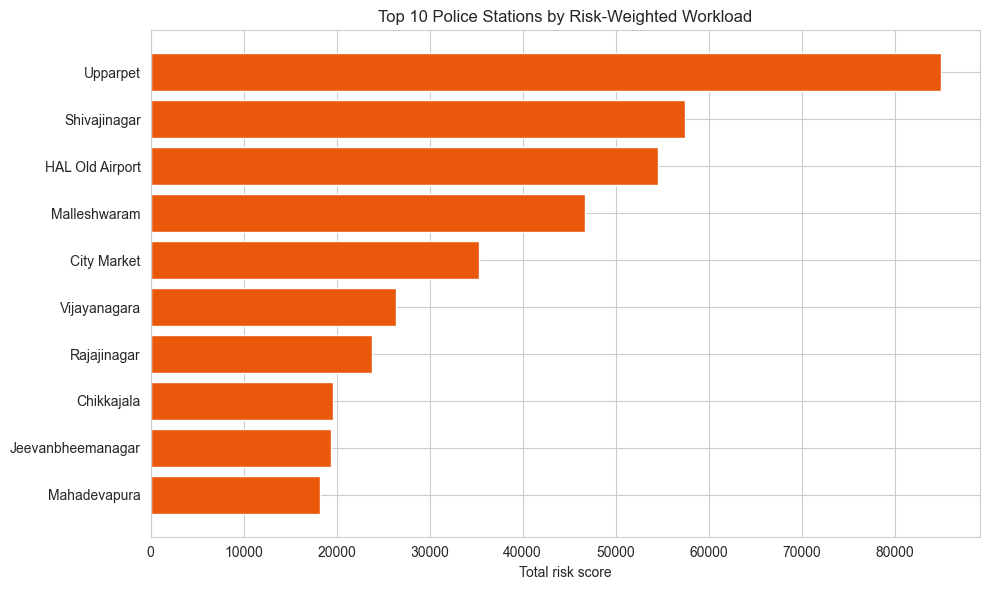

,police_station,count,total_risk,avg_risk,peak_hour
47,Upparpet,16137,84920,5.26,9
45,Shivajinagar,11784,57420,4.87,10
14,HAL Old Airport,8423,54572,6.48,4
36,Malleshwaram,8955,46737,5.22,8
10,City Market,6607,35328,5.35,9
49,Vijayanagara,6473,26399,4.08,11
42,Rajajinagar,4182,23778,5.69,10
9,Chikkajala,2393,19622,8.20,4
25,Jeevanbheemanagar,3305,19397,5.87,7
35,Mahadevapura,2397,18186,7.59,6


In [78]:
# ── F. Police station workload ─────────────────────────────
station = df.groupby("police_station").agg(
    count=("id","count"), total_risk=("risk_score_raw","sum"),
    avg_risk=("risk_score_raw","mean"),
    peak_hour=("hour_ist", lambda x: int(x.mode()[0]))
).round(2).reset_index().sort_values("total_risk", ascending=False)

fig, ax = plt.subplots(figsize=(10,6))
top_station = station.head(10).sort_values("total_risk")
ax.barh(top_station["police_station"], top_station["total_risk"], color="#ea580c")
ax.set_xlabel("Total risk score")
ax.set_title("Top 10 Police Stations by Risk-Weighted Workload")
plt.tight_layout(); plt.show()
station.head(10)


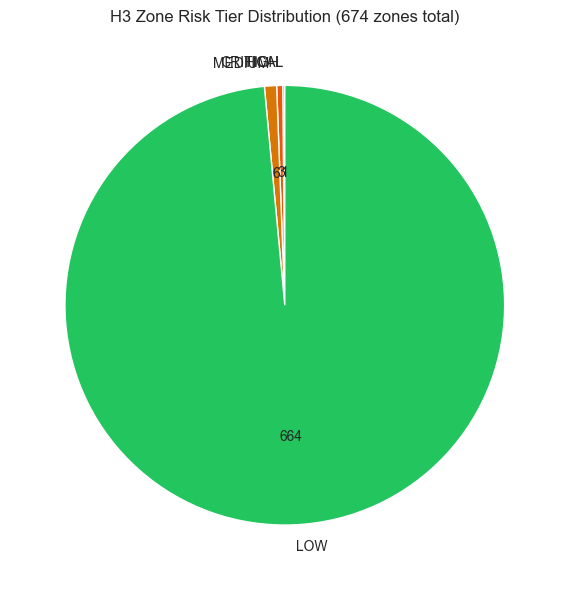

risk_tier
CRITICAL      1
HIGH          3
MEDIUM        6
LOW         664
Name: count, dtype: int64


In [79]:
# ── G. Risk tier distribution across H3 zones ──────────────
tier_counts = hexdf["risk_tier"].value_counts().reindex(["CRITICAL","HIGH","MEDIUM","LOW"], fill_value=0)

fig, ax = plt.subplots(figsize=(6,6))
colors_pie = ["#dc2626","#ea580c","#d97706","#22c55e"]
ax.pie(tier_counts, labels=tier_counts.index, autopct=lambda p: f"{int(p*sum(tier_counts)/100)}" if p>0 else "",
       colors=colors_pie, startangle=90)
ax.set_title(f"H3 Zone Risk Tier Distribution ({len(hexdf)} zones total)")
plt.tight_layout(); plt.show()

print(tier_counts)


In [80]:
# ── Key findings summary ───────────────────────────────────
peak_gap = len(df[df["hour_ist"].between(9,16)])

print("="*60)
print("KEY FINDINGS — PHASE 1 EDA")
print("="*60)
print(f'''
Dataset       : {len(df):,} violations  ({df["date"].min()} → {df["date"].max()})
Coverage      : {df["police_station"].nunique()} police stations, {df["junction_resolved"].nunique()} zones
H3 zones      : {len(hexdf)} hex cells | CRITICAL+HIGH: {(hexdf.risk_tier.isin(["CRITICAL","HIGH"])).sum()}

TOP HOTSPOT   : {top_jn.iloc[0]["junction_resolved"]}
                ({int(top_jn.iloc[0]["count"]):,} violations, risk score {int(top_jn.iloc[0]["total_risk"]):,})

ENFORCEMENT GAP
  Violations during peak traffic hours (9am-4pm) : {peak_gap:,} ({peak_gap/len(df)*100:.1f}%)
  Records validated/approved                      : {df["is_validated"].sum():,} ({df["is_validated"].mean()*100:.1f}%)
  Records sent to SCITA                            : {df["data_sent_to_scita"].sum():,} ({df["data_sent_to_scita"].mean()*100:.1f}%)
''')


KEY FINDINGS — PHASE 1 EDA

Dataset       : 122,404 violations  (2023-11-09 → 2024-03-29)
Coverage      : 54 police stations, 596 zones
H3 zones      : 674 hex cells | CRITICAL+HIGH: 4

TOP HOTSPOT   : BTP051 - Safina Plaza Junction
                (10,282 violations, risk score 50,151)

ENFORCEMENT GAP
  Violations during peak traffic hours (9am-4pm) : 49,611 (40.5%)
  Records validated/approved                      : 115,350 (94.2%)
  Records sent to SCITA                            : 122,401 (100.0%)



## 7. Interactive Folium Heatmap

A multi-layer map: H3 risk-tier choropleth, raw violation density heatmap, and
the top-25 hotspot junctions as clickable markers. Saved as a standalone HTML file.


In [81]:
BLR_CENTER = [12.9716, 77.5946]

m = folium.Map(location=BLR_CENTER, zoom_start=12, tiles="CartoDB Positron", prefer_canvas=True)
MiniMap(toggle_display=True).add_to(m)

TIER_COLORS  = {"CRITICAL":"#DC2626", "HIGH":"#EA580C", "MEDIUM":"#D97706", "LOW":"#4ADE80"}
TIER_OPACITY = {"CRITICAL":0.75, "HIGH":0.65, "MEDIUM":0.50, "LOW":0.20}

hex_layer = folium.FeatureGroup(name="Risk heatmap (H3 hexagons)", show=True)

for _, row in hexdf.iterrows():
    tier = row["risk_tier"]
    color = TIER_COLORS.get(tier, "#94a3b8")
    opacity = TIER_OPACITY.get(tier, 0.15)
    boundary = h3.cell_to_boundary(row["h3_cell"])
    polygon_coords = [[lat, lon] for lat, lon in boundary]

    popup_html = f'''<div style="font-family:sans-serif;font-size:13px;min-width:200px">
      <b>{row["dominant_station"]}</b><br>
      Violations: <b>{int(row["count"]):,}</b><br>
      Risk score: <b>{int(row["total_risk"]):,}</b><br>
      Tier: <b style="color:{color}">{tier}</b><br>
      Top type: {row["dominant_type"]}<br>
      Top vehicle: {row["dominant_vehicle"]}
      </div>'''

    folium.Polygon(
        locations=polygon_coords, color=color, weight=0.5, fill=True,
        fill_color=color, fill_opacity=opacity,
        popup=folium.Popup(popup_html, max_width=280),
        tooltip=f"{tier} | {int(row['count']):,} violations",
    ).add_to(hex_layer)

hex_layer.add_to(m)
print("✓ H3 choropleth layer added")


✓ H3 choropleth layer added


In [82]:
heat_layer = folium.FeatureGroup(name="Raw violation density", show=False)
heat_data = df[["latitude","longitude","risk_score_raw"]].dropna().values.tolist()
HeatMap(heat_data, radius=12, blur=15, max_zoom=14,
        gradient={0.2:"#4ade80", 0.5:"#fbbf24", 0.8:"#ef4444", 1.0:"#7f1d1d"}).add_to(heat_layer)
heat_layer.add_to(m)
print("✓ Raw heatmap layer added")


✓ Raw heatmap layer added


In [83]:
jn_layer = folium.FeatureGroup(name="Top 25 enforcement zones", show=True)
mc = MarkerCluster().add_to(jn_layer)

for rank, (_, row) in enumerate(top_jn.head(25).iterrows(), 1):
    icon_color = "red" if rank <= 5 else "orange" if rank <= 10 else "blue"
    popup_html = f'''<div style="font-family:sans-serif;font-size:13px;min-width:240px">
      <b>#{rank} — {row["junction_resolved"]}</b><br><br>
      Violations: <b>{int(row["count"]):,}</b><br>
      Risk score: <b>{int(row["total_risk"]):,}</b><br>
      Main road parking: {row["main_road_pct"]:.1f}%<br>
      Top violation: {row["dominant_type"]}<br>
      Top vehicle: {row["dominant_vehicle"]}
      </div>'''
    folium.Marker(
        location=[row["lat"], row["lon"]],
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"#{rank} {row['junction_resolved'][:30]} | {int(row['count']):,} violations",
        icon=folium.Icon(color=icon_color, icon="exclamation-sign", prefix="glyphicon"),
    ).add_to(mc)

jn_layer.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)
print("✓ Junction marker layer added (25 markers)")


✓ Junction marker layer added (25 markers)


In [84]:
from pathlib import Path

map_path = Path("bengaluru_parking_heatmap.html")
m.save(str(map_path))

print(f"✓ Map saved to {map_path.resolve()}")

✓ Map saved to C:\Users\LENOVO\Flipkart Gridlock\bengaluru_parking_heatmap.html


## 8. Export Artifacts for Phase 2

In [85]:
# Save all cleaned datasets + EDA tables for the next phase
from pathlib import Path

OUTPUT_DIR = Path(".")

df.to_csv(OUTPUT_DIR / "violations_geocoded.csv", index=False)
hexdf.to_csv(OUTPUT_DIR / "h3_hexagons.csv", index=False)
top_jn.to_csv(OUTPUT_DIR / "eda_top_junctions.csv", index=False)
hourly.to_csv(OUTPUT_DIR / "eda_hourly.csv", index=False)
daily.to_csv(OUTPUT_DIR / "eda_daily.csv", index=False)
monthly.to_csv(OUTPUT_DIR / "eda_monthly.csv", index=False)
veh.to_csv(OUTPUT_DIR / "eda_vehicle_risk.csv", index=False)
station.to_csv(OUTPUT_DIR / "eda_station_load.csv", index=False)

print("✓ All Phase 1 artifacts saved to /kaggle/working/:")
for f in sorted(OUTPUT_DIR.glob("*.csv")) :
    print(f"   {f.name}")
print(f"   {map_path.name}")

print(f"\n✓ PHASE 1 COMPLETE — {len(df):,} violations processed, {len(hexdf)} hotspot zones mapped")
print("  Next: Phase 2 — DBSCAN clustering + congestion risk prediction model")


✓ All Phase 1 artifacts saved to /kaggle/working/:
   daily_timeseries_features.csv
   dbscan_hotspot_clusters.csv
   eda_daily.csv
   eda_hourly.csv
   eda_monthly.csv
   eda_station_load.csv
   eda_top_junctions.csv
   eda_vehicle_risk.csv
   enforcement_priority_ranking.csv
   h3_hexagons.csv
   h3_hexagons_with_cii.csv
   jan to may police violation_anonymized791b166.csv
   violations_geocoded.csv
   bengaluru_parking_heatmap.html

✓ PHASE 1 COMPLETE — 122,404 violations processed, 674 hotspot zones mapped
  Next: Phase 2 — DBSCAN clustering + congestion risk prediction model
